### Import Necessary Packages

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning / Model Validation 
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GridSearchCV

from collections import defaultdict


In [4]:
user_movies = pd.read_csv("../data/initial_modeling_data.csv")

In [5]:
user_movies.shape

(257, 240)

In [6]:
user_movies.head()

,Name,Year,Rating,tmdb_id,genres,director,cast,cast_Matt Damon,cast_Edward Norton,cast_Robert De Niro,...,director_clean_Denis Villeneuve,director_clean_Jimmy Chin,director_clean_Martin Scorsese,director_clean_Other,director_clean_Paul Thomas Anderson,director_clean_Quentin Tarantino,director_clean_Rian Johnson,director_clean_Stanley Kubrick,director_clean_Steven Spielberg,director_clean_Wes Anderson
0,The Usual Suspects,1995,5.0,629.0,"['Drama', 'Crime', 'Thriller']",Bryan Singer,"['Stephen Baldwin', 'Gabriel Byrne', 'Benicio ...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
1,Good Will Hunting,1997,5.0,489.0,['Drama'],Gus Van Sant,"['Matt Damon', 'Robin Williams', 'Ben Affleck'...",1,0,0,...,False,False,False,True,False,False,False,False,False,False
2,Scream,1996,5.0,4232.0,"['Crime', 'Horror', 'Mystery']",Wes Craven,"['Neve Campbell', 'Skeet Ulrich', 'Rose McGowa...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
3,A Few Good Men,1992,5.0,881.0,['Drama'],Rob Reiner,"['Tom Cruise', 'Jack Nicholson', 'Demi Moore',...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
4,No Country for Old Men,2007,5.0,6977.0,"['Crime', 'Thriller', 'Western']",Joel Coen,"['Javier Bardem', 'Tommy Lee Jones', 'Josh Bro...",0,0,0,...,False,False,False,True,False,False,False,False,False,False


In [42]:
user_movies.columns.to_list()

['Name',
 'Year',
 'Rating',
 'tmdb_id',
 'genres',
 'director',
 'cast',
 'cast_Matt Damon',
 'cast_Edward Norton',
 'cast_Robert De Niro',
 'cast_Christian Bale',
 'cast_Brad Pitt',
 'cast_Leonardo DiCaprio',
 'cast_Josh Brolin',
 'cast_Ryan Gosling',
 'cast_Anne Hathaway',
 'cast_Ralph Fiennes',
 'cast_Timothée Chalamet',
 'cast_Emily Blunt',
 'cast_Bradley Cooper',
 'cast_Jack Nicholson',
 'cast_Gwyneth Paltrow',
 'cast_Joaquin Phoenix',
 'cast_Rachel McAdams',
 'cast_Robert Pattinson',
 'cast_Benicio del Toro',
 'cast_Kevin Spacey',
 'cast_Tom Cruise',
 'cast_Harvey Keitel',
 'cast_Tom Hanks',
 'cast_Daniel Craig',
 'cast_Rosamund Pike',
 'cast_Tom Hardy',
 'cast_Frances McDormand',
 'cast_Andrew Garfield',
 'cast_Jason Schwartzman',
 'cast_Ray Liotta',
 'cast_Philip Seymour Hoffman',
 'cast_Cillian Murphy',
 'cast_Dev Patel',
 'cast_Ben Affleck',
 'cast_Javier Bardem',
 'cast_Woody Harrelson',
 'cast_Laurence Fishburne',
 'cast_Adrien Brody',
 'cast_Willem Dafoe',
 'cast_Michael 

In [45]:
X = user_movies.drop(columns=["Rating", "genres", "cast", "tmdb_id", "Name", "director"])
Y = user_movies["Rating"]

In [46]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Columns: 234 entries, Year to director_clean_Wes Anderson
dtypes: bool(14), int64(220)
memory usage: 445.4 KB


In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [48]:
model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

In [49]:
model.fit(X_train, Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [50]:
y_pred = model.predict(X_test)

In [51]:
rmse = mean_squared_error(Y_test, y_pred) ** 0.5
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 0.6850395368215371


##### Is the model adding value?

In [53]:
baseline_pred = np.repeat(Y_train.mean(), len(Y_test))

baseline_rmse = np.sqrt(
    mean_squared_error(Y_test, baseline_pred)
)

print("Baseline RMSE:", baseline_rmse)
print("XGBoost RMSE:", 0.685)

Baseline RMSE: 0.6991974270931798
XGBoost RMSE: 0.685


##### The XGBoost Regressor does basically nothing to reduce RMSE. Tune the model

In [54]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, Y_train)

print("Best parameters:")
print(search.best_params_)

print("Best CV RMSE:")
print(-search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV RMSE:
0.6773421187693783


In [55]:
from sklearn.metrics import mean_squared_error

best_model = search.best_estimator_

pred = best_model.predict(X_test)

test_rmse = np.sqrt(
    mean_squared_error(Y_test, pred)
)

print("Final test RMSE:", test_rmse)

Final test RMSE: 0.646147956111659


##### Which Features are most important to my Rankings?

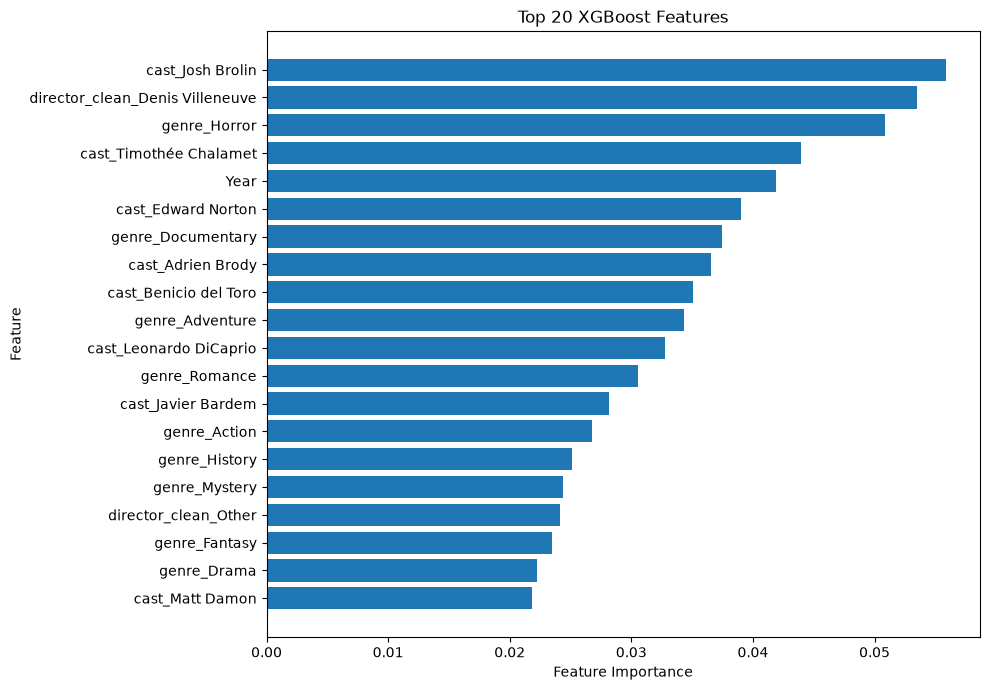

In [56]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

importance = (
    importance
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance["feature"][::-1],
    importance["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

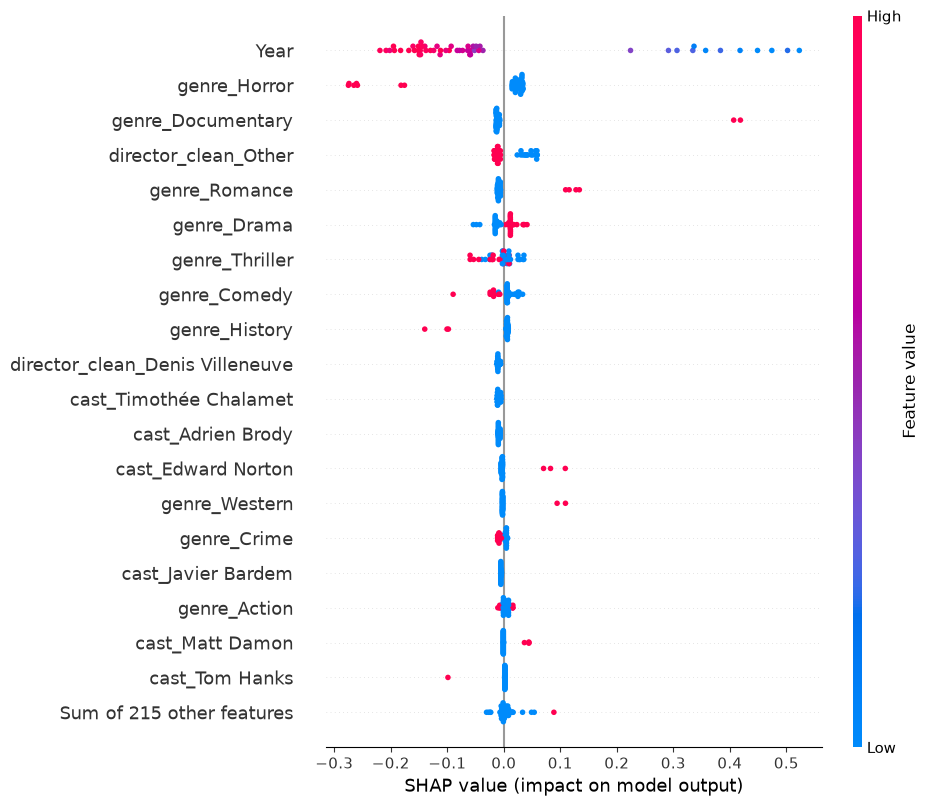

In [58]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=20)

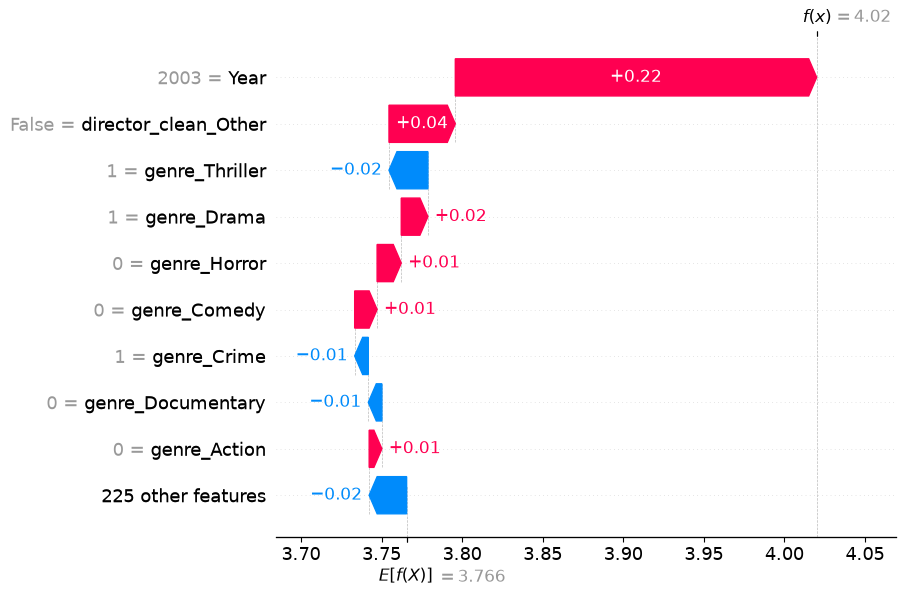

In [59]:
movie_index = 0

shap.plots.waterfall(
    shap_values[movie_index]
)